In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

---

In [26]:
# =============================
# Decane
# =============================
grid_size = np.array([
1,
0.7071067812,
0.5,
0.3535533906,
0.25,
0.1767766953,
0.125,
0.08838834765,
0.0625,
0.03125,
])

total_time = np.array([
30.68687992,
26.56054196,
21.65721045,
16.43677492,
12.80262149,
12.01621063,
10.53673507,
11.17976656,
12.37293277,
26.29554418
])

In [37]:
# =============================
# Tip4p
# =============================
grid_size = np.array([
1,
0.5,
0.25,
0.125,
0.0625,
0.03125,
0.015625
])

total_time = np.array([
127.2666688,
90.08096099,
49.3207386,
18.69831381,
16.24781169,
30.29732884,
136.8390987
])

In [2]:
# =============================
# Decane / Tip4p / phi 0.5
# =============================
grid_size = np.array([
1,
0.5,
0.25,
0.125,
0.0625,
0.03125
])

total_time = np.array([
242.0963015,
198.3829268,
134.2165258,
95.33766788,
92.04637354,
118.5058259
])

In [5]:
# =============================
# Decane / Tip4p / phi 0.25
# =============================
grid_size = np.array([
0.25,
0.125,
0.0625,
0.03125
])

total_time = np.array([
186.0406364,
134.4204617,
128.696249,
153.719626
])

In [37]:
# =============================
# Decane / Tip4p / phi 0.75
# =============================
grid_size = np.array([
0.5,
0.25,
0.125,
0.0625,
0.03125
])

total_time = np.array([
128.987552,
89.02140877,
60.29379356,
59.4246835,
84.77599278
])

In [22]:
# =============================
# Decane / Tip4p / phi 1.0
# =============================
grid_size = np.array([
0.5,
0.25,
0.125,
0.0625,
0.03125
])

total_time = np.array([
43.53804998,
25.77786963,
22.58472107,
24.95887747,
53.26259979
])

Minimum grid_size (from fit): 0.08681


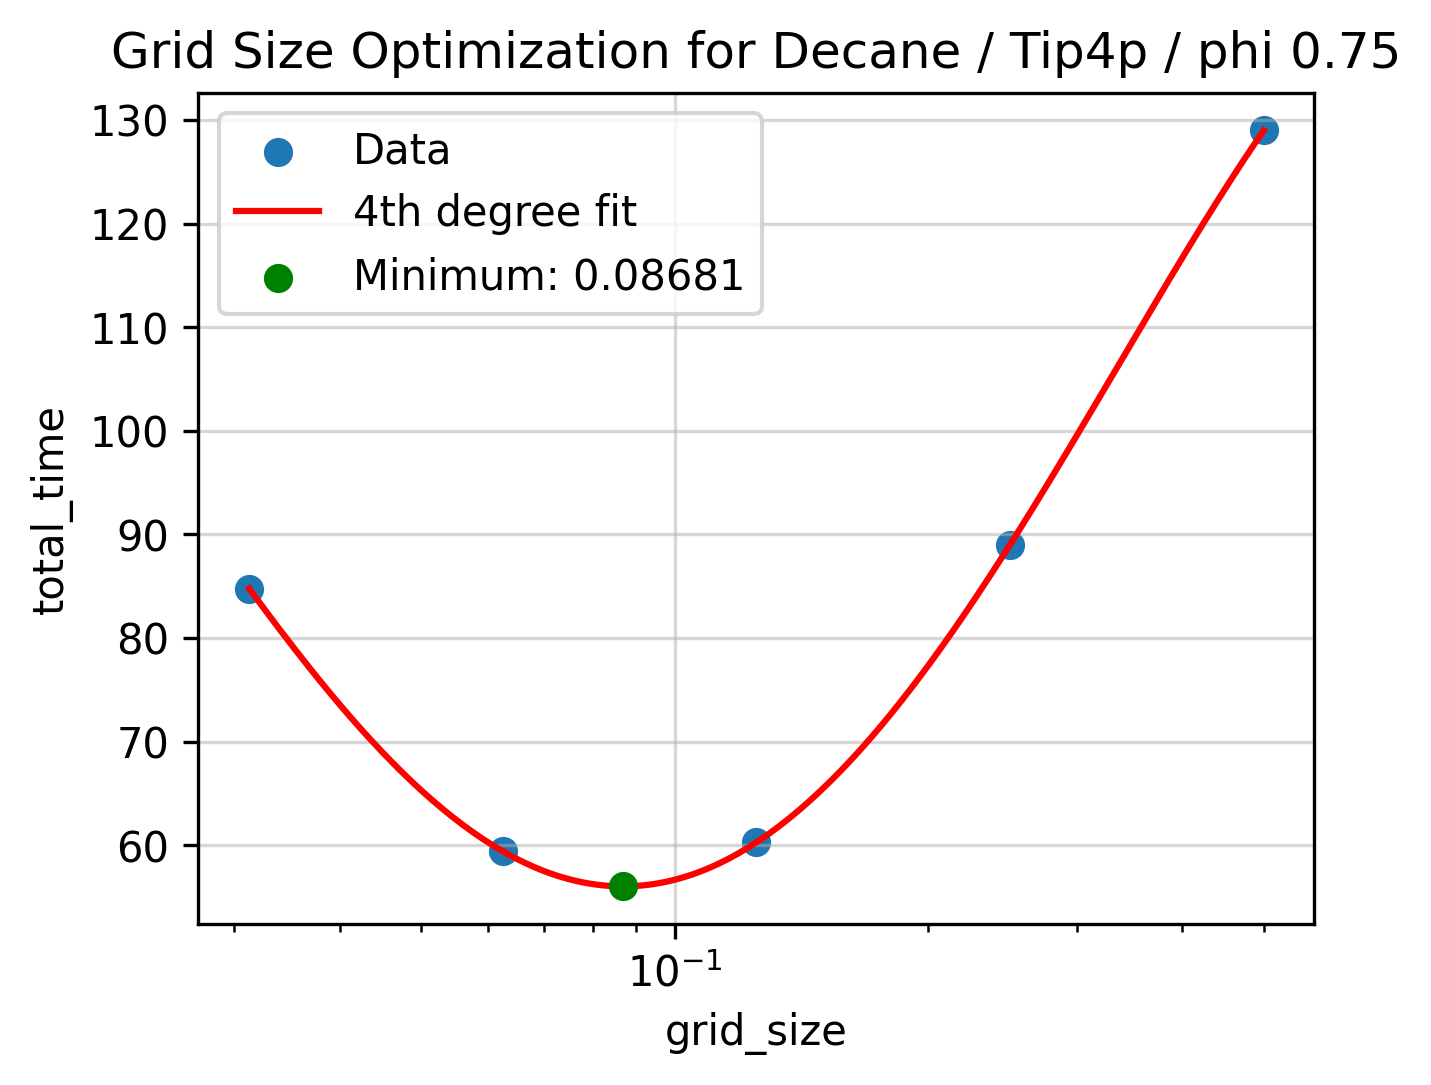

In [39]:
scale = 0.6
plt.figure(figsize=(8 * scale, 6 * scale), dpi=300)
plt.grid(alpha=0.5)

# Fit a 4th degree polynomial to the data
coeffs = np.polyfit(np.log(grid_size), total_time, 4)
poly = np.poly1d(coeffs)

# Generate fine x values for smooth curve
x_fine = np.linspace(np.log(grid_size).min(), np.log(grid_size).max(), 200)
y_fine = poly(x_fine)

# Find minimum of the polynomial fit
res = minimize_scalar(poly, bounds=(np.log(grid_size).min(), np.log(grid_size).max()), method='bounded')
min_log_grid_size = res.x
min_grid_size = np.exp(min_log_grid_size)
min_total_time = poly(min_log_grid_size)
print(f"Minimum grid_size (from fit): {min_grid_size:.5f}")

# Plot scatter and polynomial fit
plt.scatter(grid_size, total_time, label='Data')
plt.plot(np.exp(x_fine), y_fine, 'r-', label='4th degree fit')

# Plot the minimum point and add a label
plt.scatter([min_grid_size], [min_total_time], color='green', zorder=5, label=f'Minimum: {min_grid_size:.5f}')

plt.xscale('log')
plt.title('Grid Size Optimization for Decane / Tip4p / phi 0.75')
plt.xlabel('grid_size')
plt.ylabel('total_time')
plt.legend()
plt.show()

In [24]:
# Find minimum of the polynomial fit


res = minimize_scalar(poly, bounds=(np.log(grid_size).min(), np.log(grid_size).max()), method='bounded')
min_log_grid_size = res.x
min_grid_size = np.exp(min_log_grid_size)
print(f"Minimum grid_size (from fit): {min_grid_size:.5f}")


Minimum grid_size (from fit): 0.06466


In [21]:
0.048580628120794396

0.048580628120794396

In [17]:
(0.05 * 1000 / (3.0896 * 10))**(1/3)

1.1740571812676661

In [56]:
(0.05 * 1000 / (33328 * 4))**(1/3)

0.07211632492451552

In [ ]:
0.04858062812

In [54]:
(3090 * 10) / 1000

30.9

In [14]:
(4634 * 10 * 0.11559 + 16664 * 4 * 0.06466) / (3090 * 10 + 16664 * 4)

0.09069102683826386

In [ ]:
(4634 * 10 * (0.05 * 0.75 * 20 * 10 * 10 / (4634 * 10))**(1/3) + 16664 * 4 * (0.05 * 0.25 * 20 * 10 * 10 / (16664 * 4))**(1/3)) / (4634 * 10 + 16664 * 4)

---

In [2]:
grid_sizes = [
0.08568,
0.08095,
0.08681,
0.10116
]

phi = [0.5, 0.25, 0.75, 1.0]

decanes = np.array([3090, 1545, 4634, 6179])
tip4ps = np.array([33328, 49992, 16664, 1e-6])

magic_coeff = 0.037
grid_sizes_decane_pure = np.cbrt(magic_coeff * 20 * 10 * 10 / (decanes * 10))
grid_sizes_tip4p_pure = np.cbrt(magic_coeff * 20 * 10 * 10 / (tip4ps * 4))

grid_sizes_combined = (decanes * 10 * 0.11559 + tip4ps * 4 * 0.06466) / (decanes * 10 + tip4ps * 4)
grid_sizes_combined_from_pure = (decanes * 10 * grid_sizes_decane_pure + tip4ps * 4 * grid_sizes_tip4p_pure) / (decanes * 10 + tip4ps * 4)

In [88]:
grid_sizes_decane_pure

array([0.13379023, 0.16856513, 0.11688494, 0.10619511])

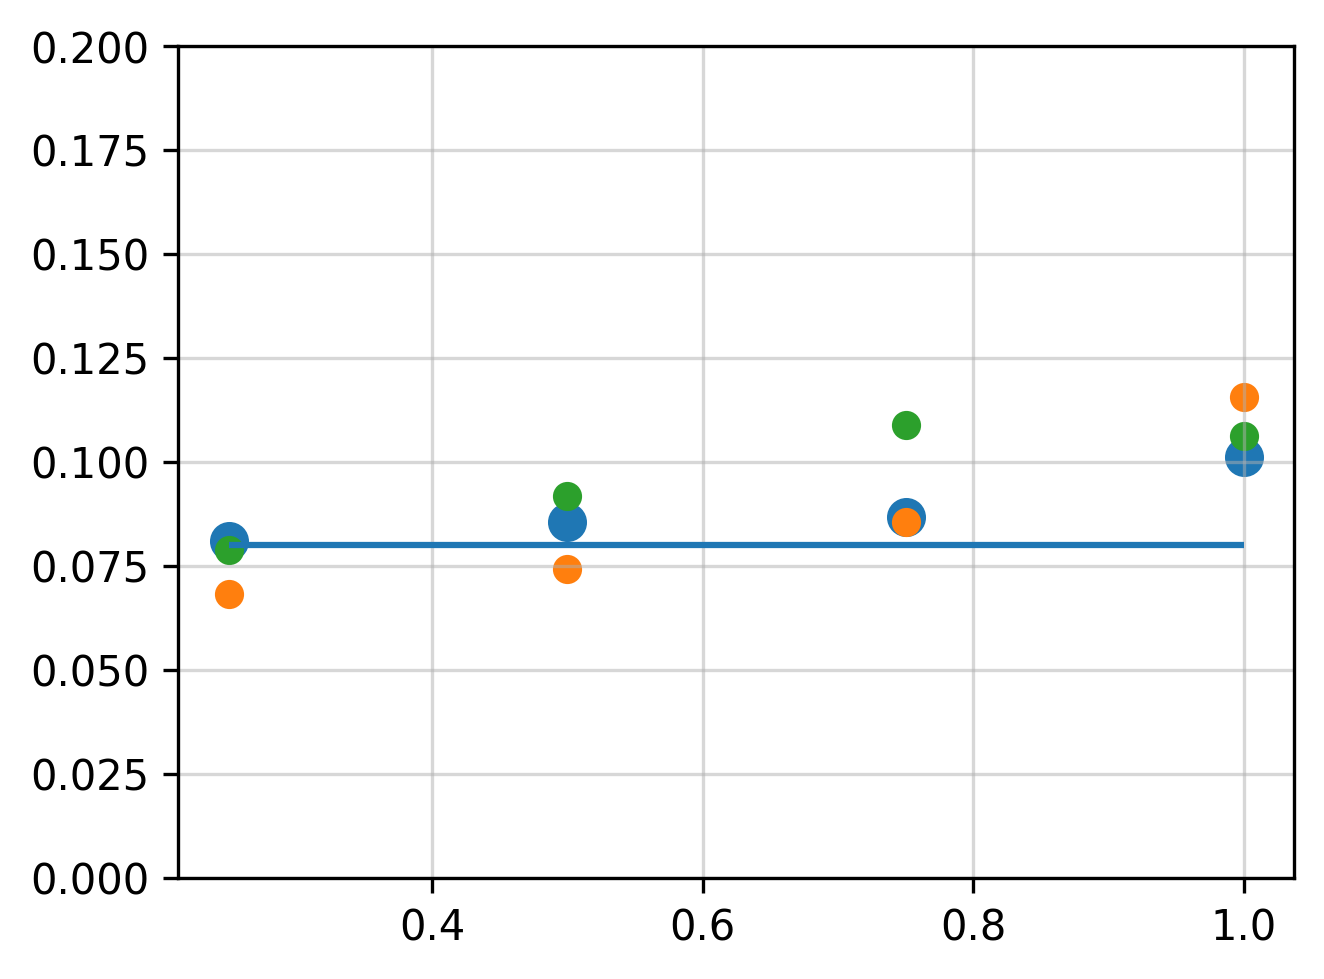

In [6]:
scale = 0.6
plt.figure(figsize=(8 * scale, 6 * scale), dpi=300)
plt.grid(alpha=0.5)
plt.scatter(phi, grid_sizes, s=70)
plt.scatter(phi, grid_sizes_combined)
plt.scatter(phi, grid_sizes_combined_from_pure)
# plt.scatter(phi, [0.08] * 4)

plt.hlines(0.08, min(phi), max(phi))

plt.ylim(bottom=0, top=0.2)
plt.show()
